In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import lightning as L
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
o_image = [[0, 0, 1, 1, 0, 0],
           [0, 1, 0, 0, 1, 0],
           [1, 0, 0, 0, 0, 1],
           [1, 0, 0, 0, 0, 1],
           [0, 1, 0, 0, 1, 0],
           [0, 0, 1, 1, 0, 0]]
o_image

[[0, 0, 1, 1, 0, 0],
 [0, 1, 0, 0, 1, 0],
 [1, 0, 0, 0, 0, 1],
 [1, 0, 0, 0, 0, 1],
 [0, 1, 0, 0, 1, 0],
 [0, 0, 1, 1, 0, 0]]

In [3]:
x_image = [[1, 0, 0, 0, 0, 1],
           [0, 1, 0, 0, 1, 0],
           [0, 0, 1, 1, 0, 0],
           [0, 0, 1, 1, 0, 0],
           [0, 1, 0, 0, 1, 0],
           [1, 0, 0, 0, 0, 1]]
x_image

[[1, 0, 0, 0, 0, 1],
 [0, 1, 0, 0, 1, 0],
 [0, 0, 1, 1, 0, 0],
 [0, 0, 1, 1, 0, 0],
 [0, 1, 0, 0, 1, 0],
 [1, 0, 0, 0, 0, 1]]

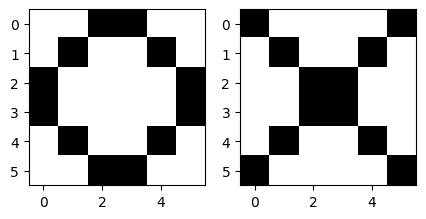

In [4]:
fig, axarr = plt.subplots(nrows=1, ncols=2, figsize=(5, 5))

axarr[0].imshow(o_image, cmap='gray_r')
axarr[1].imshow(x_image, cmap='gray_r')


In [5]:
input_images = torch.tensor([o_image, x_image]).type(torch.float32)

In [7]:
input_labels = torch.tensor([[1.0, 0.0], [0.0, 1.0]]).type(torch.float32)

In [8]:
dataset = TensorDataset(input_images, input_labels)
dataloader = DataLoader(dataset)

In [12]:
for batch_num, (images, labels) in enumerate(dataloader):
    print('batch_num:', batch_num)
    print(images)
    print(labels)


batch_num: 0
tensor([[[0., 0., 1., 1., 0., 0.],
         [0., 1., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 1.],
         [1., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 1., 0., 0.]]])
tensor([[1., 0.]])
batch_num: 1
tensor([[[1., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 1., 0., 0.],
         [0., 0., 1., 1., 0., 0.],
         [0., 1., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 1.]]])
tensor([[0., 1.]])


In [20]:
class SimpleCNN(L.LightningModule):
    def __init__(self):
        super().__init__()
        L.seed_everything(seed=42)
        self.conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.input_to_hidden = nn.Linear(in_features=4, out_features=1)
        self.hidden_to_output = nn.Linear(in_features=1, out_features=2)
        self.loss = nn.CrossEntropyLoss()
        
    def forward(self, x):
        x = self.conv(x)
        x = F.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.input_to_hidden(x)
        x = F.relu(x)
        x = self.hidden_to_output(x)
        
        return x 
    
    def configure_optimizers(self):
        return Adam(self.parameters(), lr=1e-3)
    
    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self.forward(inputs)
        loss = self.loss(outputs, labels)
        
        return loss

In [21]:
model = SimpleCNN()

Seed set to 42


In [22]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(model, train_dataloaders=dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv             │ Conv2d           │     10 │ train │     0 │
│ 1 │ pool             │ MaxPool2d        │      0 │ train │     0 │
│ 2 │ input_to_hidden  │ Linear           │      5 │ train │     0 │
│ 3 │ hidden_to_output │ Linear           │      4 │ train │     0 │
│ 4 │ loss             │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 19                                                                                               
Non-trainable params: 0                                                                                            
Total params: 19                                                                                                   
Total estimated model params size (MB): 0.000                                                                      
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=100` reached.


In [ ]:
for batch_num, (image, label) in enumerate(dataloader):
    prediction = model(image)
    predicted_label = torch.round(torch.softmax(prediction, dim=1),decimals=2)
    
    print('predicted_label:', predicted_label)
    print('oringinal_label', label)
    print('\n')

predicted_label: tensor([[0.5200, 0.4800]], grad_fn=<RoundBackward1>)
oringinal_label tensor([[1., 0.]])


predicted_label: tensor([[0.4200, 0.5800]], grad_fn=<RoundBackward1>)
oringinal_label tensor([[0., 1.]])




In [25]:
path_to_checkpoint = trainer.checkpoint_callback.best_model_path


In [26]:
trainer = L.Trainer(max_epochs=700)
trainer.fit(model, train_dataloaders=dataloader, ckpt_path=path_to_checkpoint)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Restoring states from the checkpoint path at /Users/chengtechang/Desktop/vs/DL_ch/lightning_logs/version_4/checkpoints/epoch=99-step=200.ckpt
/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:566: The dirpath has changed from '/Users/chengtechang/Desktop/vs/DL_ch/lightning_logs/version_4/checkpoints' to '/Users/chengtechang/Desktop/vs/DL_ch/lightning_logs/version_5/checkpoints', therefore `best_model_score`, `kth_best_

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv             │ Conv2d           │     10 │ train │     0 │
│ 1 │ pool             │ MaxPool2d        │      0 │ train │     0 │
│ 2 │ input_to_hidden  │ Linear           │      5 │ train │     0 │
│ 3 │ hidden_to_output │ Linear           │      4 │ train │     0 │
│ 4 │ loss             │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 19                                                                                               
Non-trainable params: 0                                                                                            
Total params: 19                                                                                                   
Total estimated model params size (MB): 0.000                                                                      
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Restored all states from the checkpoint at /Users/chengtechang/Desktop/vs/DL_ch/lightning_logs/version_4/checkpoints/epoch=99-step=200.ckpt


/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/chengtechang/Desktop/vs/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=700` reached.


In [27]:
for batch_num, (image, label) in enumerate(dataloader):
    prediction = model(image)
    predicted_label = torch.round(torch.softmax(prediction, dim=1),decimals=2)
    
    print('predicted_label:', predicted_label)
    print('oringinal_label', label)
    print('\n')

predicted_label: tensor([[0.7900, 0.2100]], grad_fn=<RoundBackward1>)
oringinal_label tensor([[1., 0.]])


predicted_label: tensor([[0.0100, 0.9900]], grad_fn=<RoundBackward1>)
oringinal_label tensor([[0., 1.]])




In [30]:
shifted_x_image = [[0, 1, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 1],
                   [0, 0, 0, 1, 1, 0],
                   [0, 0, 0, 1, 1, 0],
                   [0, 0, 1, 0, 0, 1],
                   [0, 1, 0, 0, 0, 0]]
shifted_x_image

[[0, 1, 0, 0, 0, 0],
 [0, 0, 1, 0, 0, 1],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 1, 0, 0, 1],
 [0, 1, 0, 0, 0, 0]]

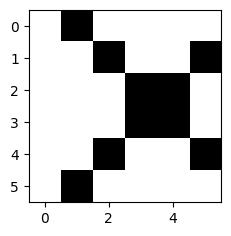

In [31]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(shifted_x_image, cmap='gray_r')

In [32]:
prediction = model(torch.tensor([shifted_x_image]).type(torch.float32))
predicted_label = torch.round(torch.softmax(prediction, dim=1), decimals=2)
predicted_label

tensor([[0.1200, 0.8800]], grad_fn=<RoundBackward1>)

In [33]:
shifted_o_image = [[0, 1, 1, 0, 0, 0],
                   [1, 0, 0, 1, 0, 0],
                   [0, 0, 0, 0, 1, 0],
                   [0, 0, 0, 0, 1, 0],
                   [1, 0, 0, 1, 0, 0],
                   [0, 1, 1, 0, 0, 0]]
shifted_o_image

[[0, 1, 1, 0, 0, 0],
 [1, 0, 0, 1, 0, 0],
 [0, 0, 0, 0, 1, 0],
 [0, 0, 0, 0, 1, 0],
 [1, 0, 0, 1, 0, 0],
 [0, 1, 1, 0, 0, 0]]

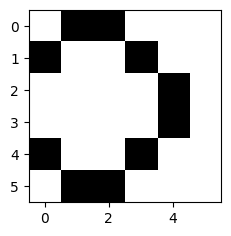

In [34]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(shifted_o_image, cmap='gray_r')

In [ ]:
prediction = model(torch.tensor([shifted_o_image]).type(torch.float32))

predicted_label = torch.round(torch.softmax(prediction, dim=1), decimals=2) 

predicted_label


tensor([[0.4500, 0.5500]], grad_fn=<RoundBackward1>)